In [43]:
import json
from collections import defaultdict
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams, font_manager
import scienceplots
import torch
from typing import List
from sklearn.metrics import f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import re



In [104]:
output_dir = '/home/slim/dpo-rhlf-paraphrase-types/out/plots'
os.chdir('/home/slim/dpo-rhlf-paraphrase-types')

TOP_10_PARAPHRASE_TYPES = [
    "addition/deletion", "change of order", "derivational changes", "inflectional changes",
    "punctuation changes", "same polarity substitution (contextual)", "semantic based",
    "spelling changes", "subordination and nesting changes", "synthetic/analytic substitution"
]

textwidth1 = 5.47807 #onecolumn
aspect_ratio = (5 ** 0.5 - 1) / 2 # golden ratio
width1 = textwidth1
height1 = width1 * aspect_ratio
textwidthcm=15.99773 #onecolumn
textwidthcm=7.82315 #twocolumn
textheightcm=textwidthcm / aspect_ratio

In [105]:
libertine_path = "/usr/share/fonts/opentype/linux-libertine/LinLibertine_R.otf"

font_dirs = ["/usr/share/fonts/opentype/linux-libertine"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    
# Function to convert CMYK to RGB
def cmyk_to_rgb(c, m, y, k):
    r = 1 - min(1, c * (1 - k) + k)
    g = 1 - min(1, m * (1 - k) + k)
    b = 1 - min(1, y * (1 - k) + k)
    return (r, g, b)

# Define colors using the CMYK values
ACMBlue = cmyk_to_rgb(1, 0.1, 0, 0.1)
ACMYellow = cmyk_to_rgb(0, 0.16, 1, 0)
ACMOrange = cmyk_to_rgb(0, 0.42, 1, 0.01)
ACMRed = cmyk_to_rgb(0, 0.90, 0.86, 0)
ACMLightBlue = cmyk_to_rgb(0.49, 0.01, 0, 0)
ACMGreen = cmyk_to_rgb(0.20, 0, 1, 0.19)
ACMPurple = cmyk_to_rgb(0.55, 1, 0, 0.15)
ACMDarkBlue = cmyk_to_rgb(1, 0.58, 0, 0.21)

acm_palette = [
    ACMBlue, ACMYellow, ACMOrange, ACMRed, 
    ACMLightBlue, ACMGreen, ACMPurple, ACMDarkBlue
]

# Results
## Effectiveness of DPO and RHLF in Paraphrase Generation

In [106]:
# Load the JSON data
with open('/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json', 'r') as file:
    data = json.load(file)

# Dictionary to store counts for each model
model_results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    kind = entry['data']['Kind']
    # Check the "APT" choice value in the annotations
    for annotation in entry['annotations']:
        for result in annotation['result']:
            if result['from_name'] == "APT":
                choice = result['value']['choices'][0]
                model_results[kind]['total'] += 1
                if choice == "Yes":
                    model_results[kind]['yes'] += 1

# Calculate accuracy for each model
apt_percentages = {model: (counts['yes'] / counts['total']) * 100
                  for model, counts in model_results.items()}


print(apt_percentages)


{'base_model': 12.376237623762377, 'etpc_model': 11.76470588235294, 'dpo_model': 35.26315789473684}


In [107]:
# Dictionary to store counts for each (model, APT) pair
results = defaultdict(lambda: {'yes': 0, 'total': 0})

# Iterate through each entry in the JSON data
for entry in data:
    # Ensure entry is a dictionary before processing
    if isinstance(entry, dict):
        kind = entry.get('data', {}).get('Kind')
        apt_value = entry.get('data', {}).get('APT')
        
        # Proceed only if both kind and apt_value are found
        if kind and apt_value:
            annotations = entry.get('annotations', [])
            
            # Check if there are annotations
            if annotations:
                for annotation in annotations:
                    results_found = annotation.get('result', [])
                    
                    # Iterate through each result within the annotation
                    for result in results_found:
                        from_name = result.get('from_name')
                        
                        # Focus on results where from_name is "APT"
                        if from_name == "APT":
                            choice = result.get('value', {}).get('choices', [None])[0]
                            
                            # Check if the choice is valid
                            if choice:
                                results[(kind, apt_value)]['total'] += 1
                                if choice == "Yes":
                                    results[(kind, apt_value)]['yes'] += 1

# Calculate accuracy for each (model, APT) pair
apt_percentages = {
    (model, apt): (counts['yes'] / counts['total']) * 100
    for (model, apt), counts in results.items()
    if counts['total'] > 0  # Avoid division by zero
}

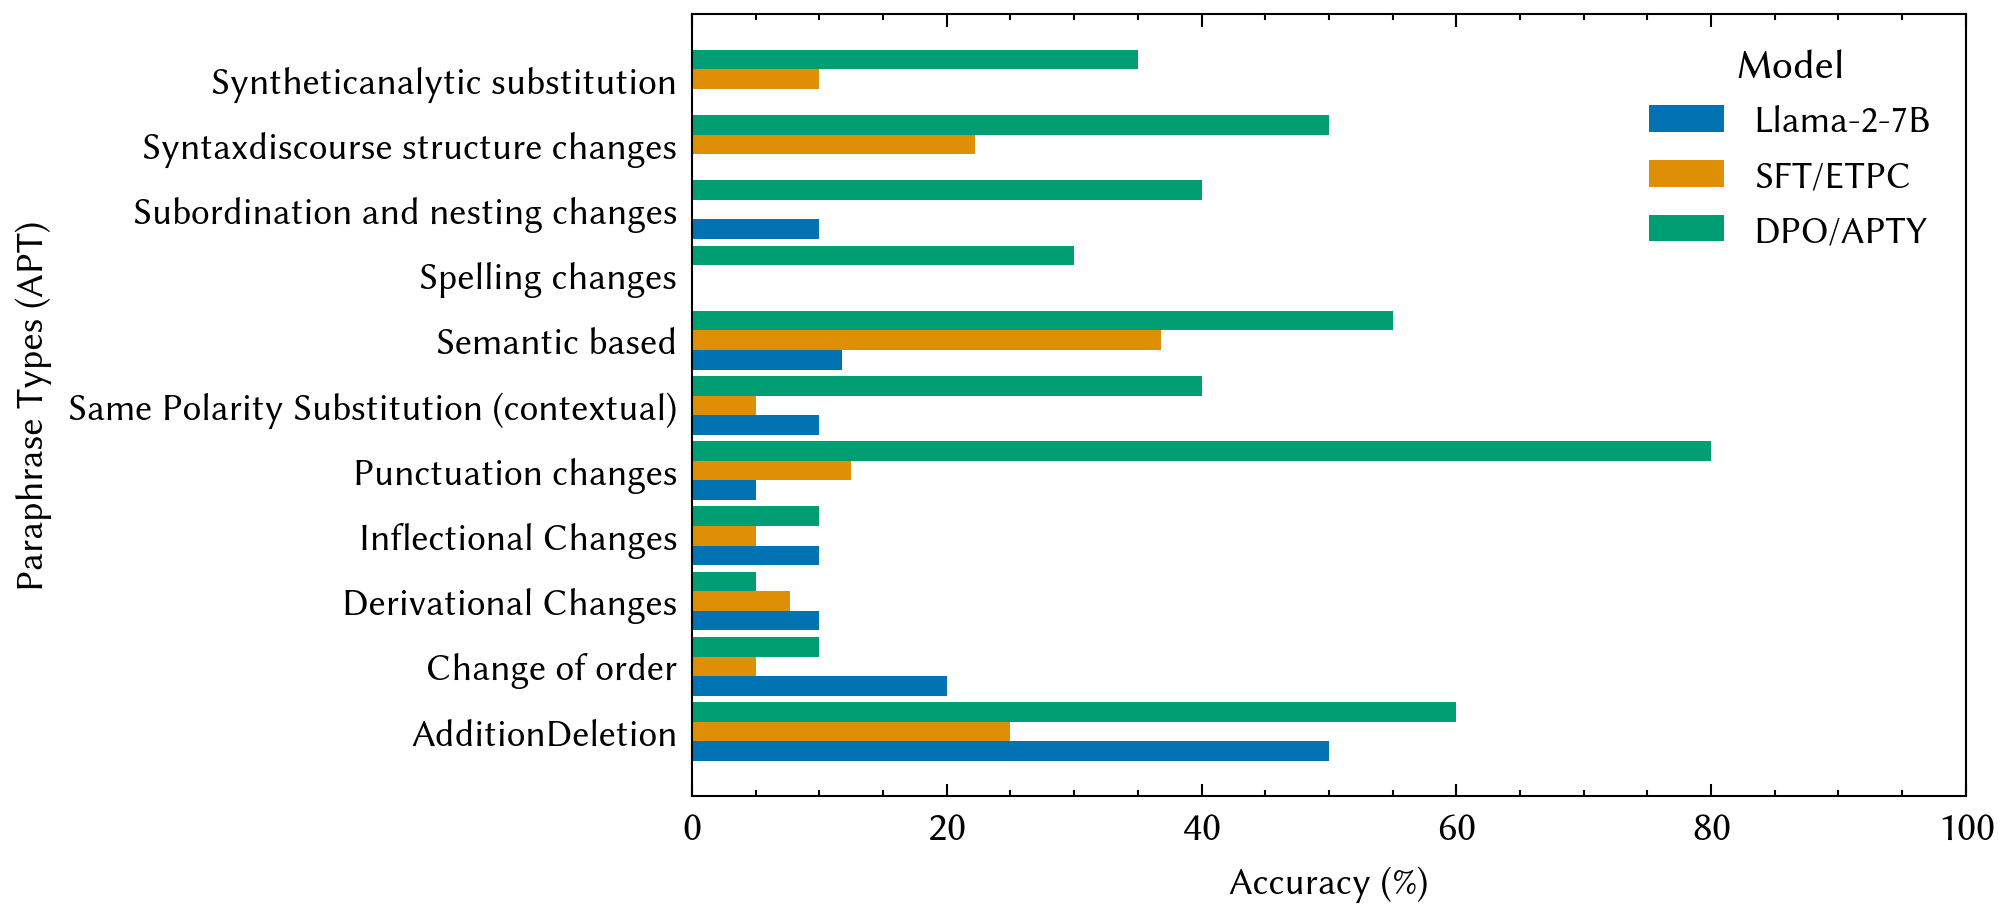

In [108]:
# Create a set of unique APT values and models in the specified order
apt_values = sorted(set(apt for _, apt in apt_percentages.keys()))
models = ["base_model", "etpc_model", "dpo_model"]  # Ordered list of models
model_labels = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY"
}

# Create data for plotting
y = np.arange(len(apt_values))  # the label locations for the y-axis
width = 0.3  # the width of the bars

# Create a dictionary to hold accuracy values for each model across APTs
model_accuracies = {
    model: [apt_percentages.get((model, apt), 0) for apt in apt_values]
    for model in models
}

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

# Plot each model's accuracy as a separate set of horizontal bars
for i, model in enumerate(models):
    plt.barh(y + i * width, model_accuracies[model], height=width, label=model_labels[model])

# Add labels and title
plt.ylabel('Paraphrase Types (APT)', fontsize=9)
plt.xlabel('Accuracy (%)', fontsize=9)
plt.yticks(y + width * (len(models) - 1) / 2, apt_values, fontsize=9)
plt.xlim(0, 100) 
plt.legend(title='Model', fontsize=9)

ax.tick_params(axis='y', which='both', left=False, right=False)

output_path = os.path.join(output_dir, "llama_type_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Display the plot
plt.show()


## Incorporating Human-Ranked Data for Improved Paraphrase Generation

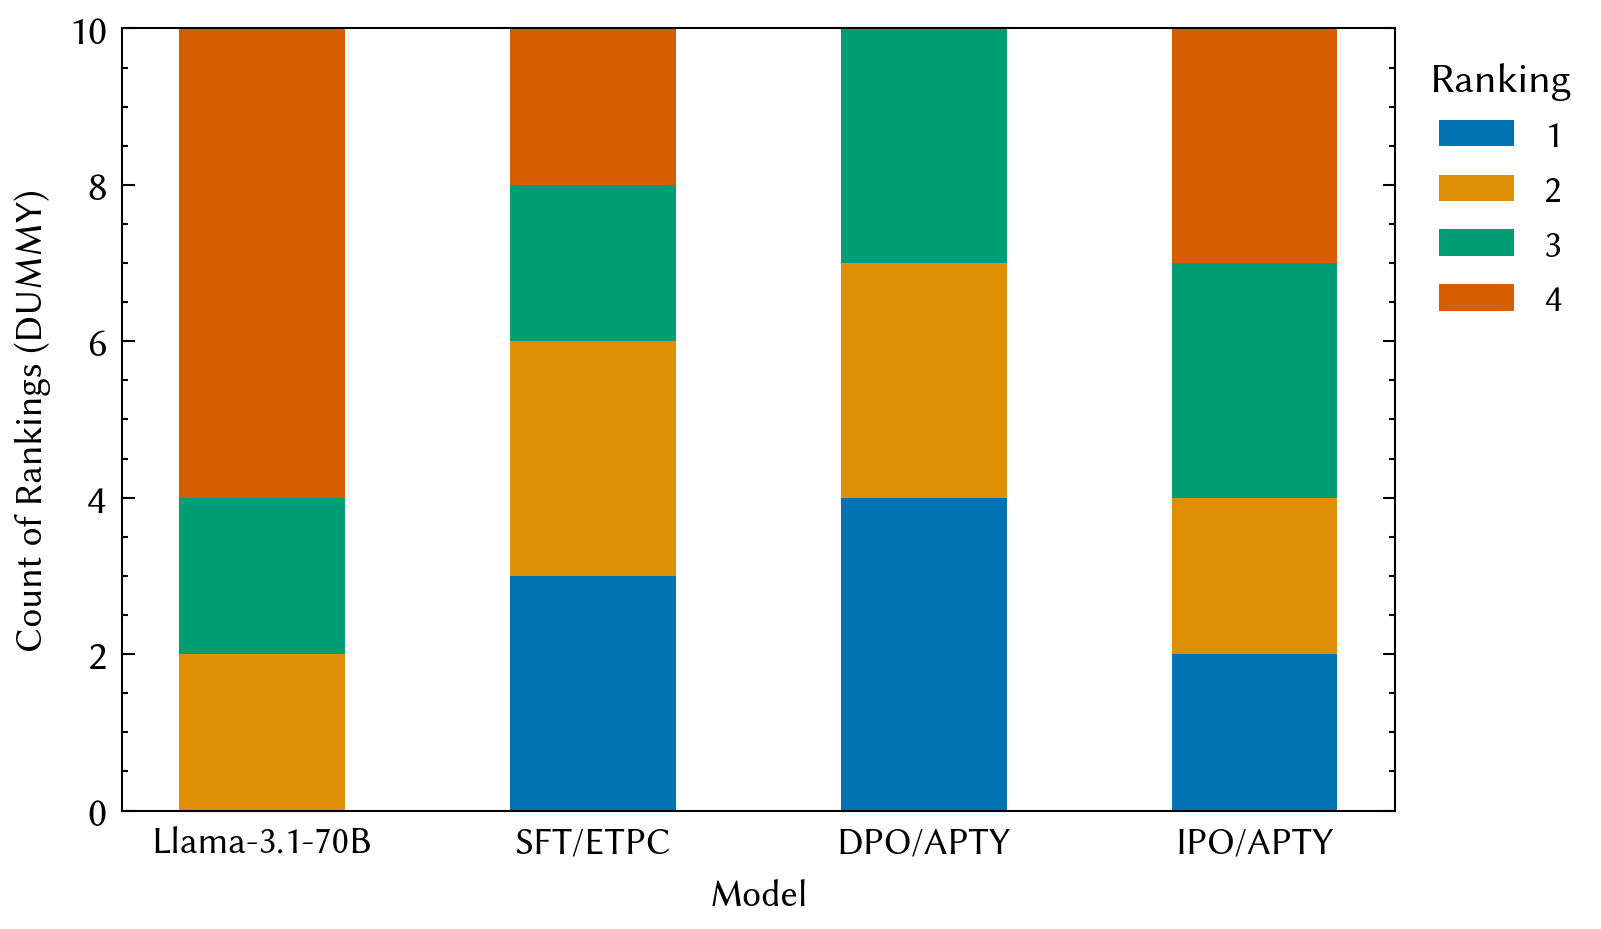

In [109]:
# Adding the base model rankings to the dummy data
data_with_base = {
    "Llama-3.1-70B": [4, 4, 4, 2, 4, 4, 3, 4, 2, 3],
    "SFT/ETPC": [1, 2, 3, 1, 2, 3, 4, 2, 1, 4],
    "DPO/APTY": [2, 1, 1, 3, 3, 2, 2, 1, 3, 1],
    "IPO/APTY": [3, 3, 2, 4, 1, 4, 1, 3, 4, 2]
}

# Convert updated data to a DataFrame
df_with_base = pd.DataFrame(data_with_base)

# Count how often each model got each ranking (1 to 4)
rank_counts_with_base = df_with_base.apply(lambda col: col.value_counts()).fillna(0).astype(int)

# Transpose for better plotting (stacked bar chart)
rank_counts_with_base = rank_counts_with_base.transpose()

# Plot the stacked bar chart with the base model
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

index = range(len(rank_counts_with_base))

for i, col in enumerate(rank_counts_with_base.columns):
    ax.bar(index, rank_counts_with_base[col], 0.5, bottom=rank_counts_with_base.iloc[:, :i].sum(axis=1))

# Set x-tick labels to the model names
ax.set_xlabel('Model', fontsize=9)
ax.set_xticks(index)
ax.set_xticklabels(rank_counts_with_base.index, fontsize=9)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelsize=9) 

ax.set_ylabel('Count of Rankings (DUMMY)', fontsize=9)

# Add legend
ax.legend(
    rank_counts_with_base.columns, 
    title="Ranking", 
    frameon=False, 
    fontsize=9, 
    bbox_to_anchor=(1.0, 1),  # Position legend outside the plot to the right
    loc='upper left'  # Align the top-left corner of the legend to this position
)

output_path = os.path.join(output_dir, "apt_ranking.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

## Broader NLP Task Improvements with Human-Ranked Data

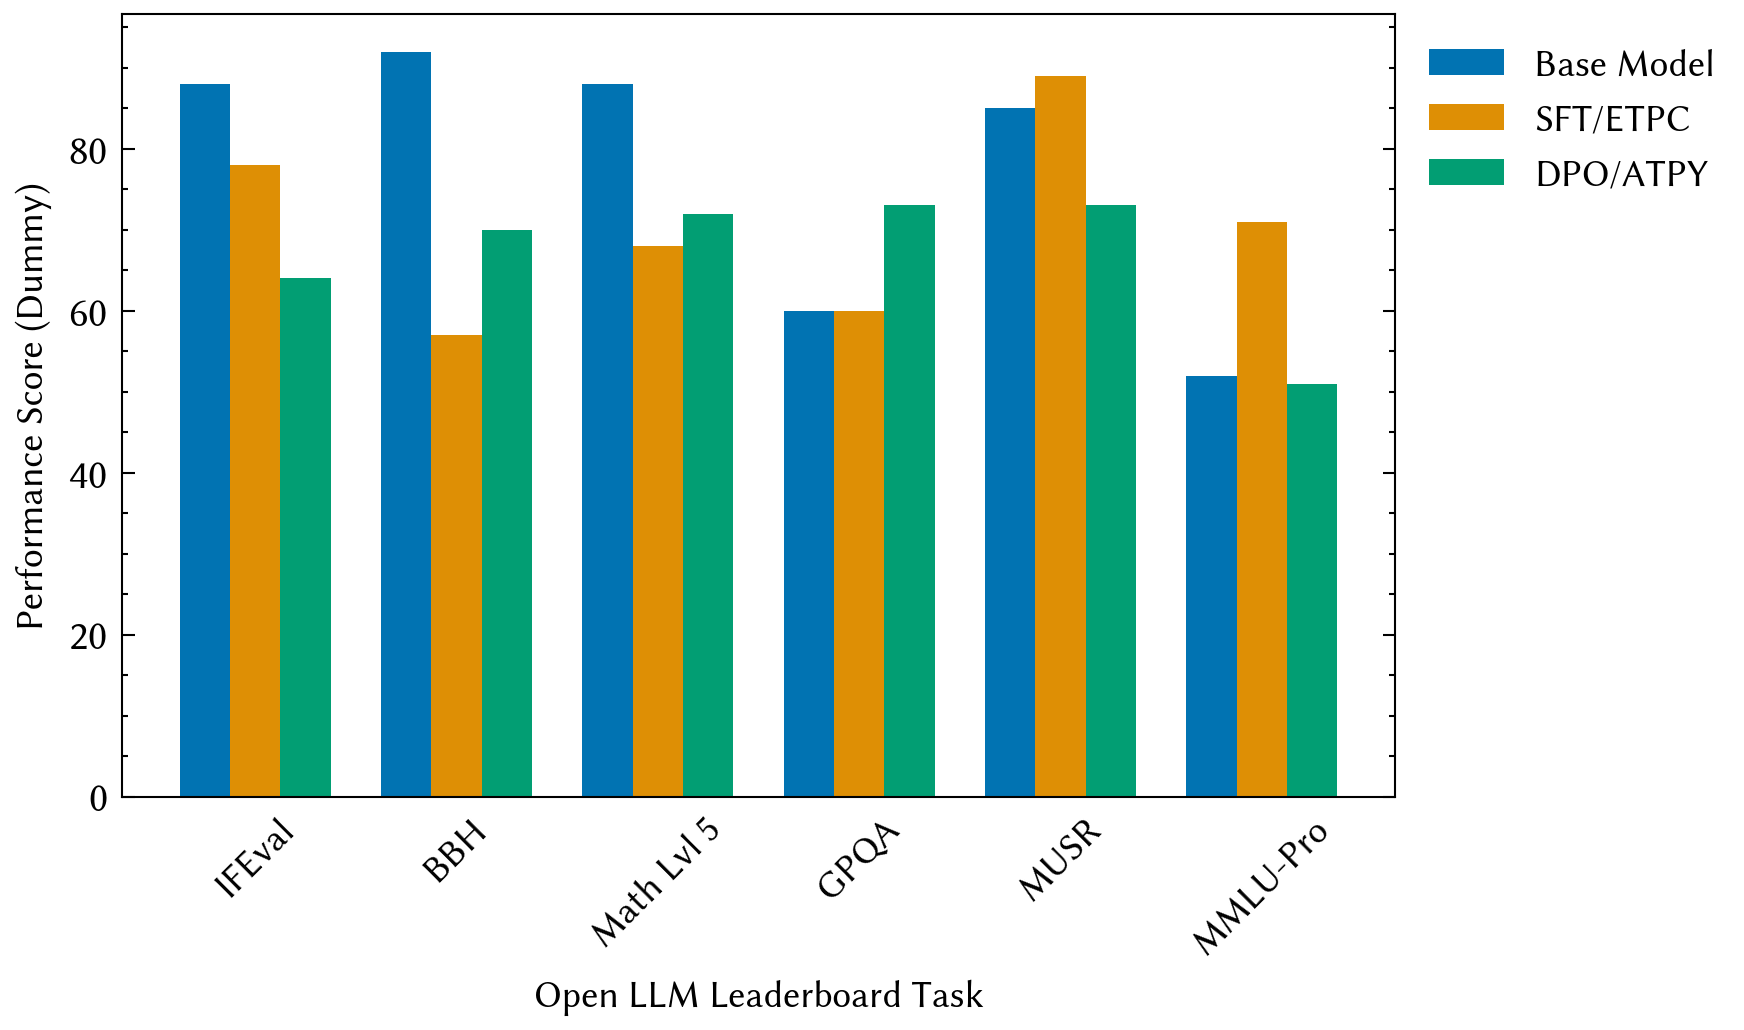

In [134]:
# Define tasks and models
tasks = ['IFEval', 'BBH', 'Math Lvl 5', 'GPQA', 'MUSR', 'MMLU-Pro']
models = ['Base Model', 'SFT/ETPC', 'DPO/ATPY']

# Create dummy scores for each task and model
np.random.seed(42)
scores = np.random.randint(50, 100, size=(len(tasks), len(models)))

# Create a grouped bar chart
# Set figure size
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

bar_width = 0.25
index = np.arange(len(tasks))

# Plot bars for each model
for i, model in enumerate(models):
    ax.bar(index + i * bar_width, scores[:, i], bar_width, label=model)

# Set labels, title, and ticks
ax.set_xlabel('Open LLM Leaderboard Task', fontsize=9)
ax.set_xticks(index + bar_width)
ax.set_xticklabels(tasks, fontsize=9)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelsize=9)
plt.xticks(rotation=45)

ax.set_ylabel('Performance Score (Dummy)', fontsize=9)

# Add legend
ax.legend(fontsize=9,
          bbox_to_anchor=(1, 1),       
          loc='upper left', 
)

output_path = os.path.join(output_dir, "llmboard.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


## Correlation Between Automatic Metrics and Human Judgment

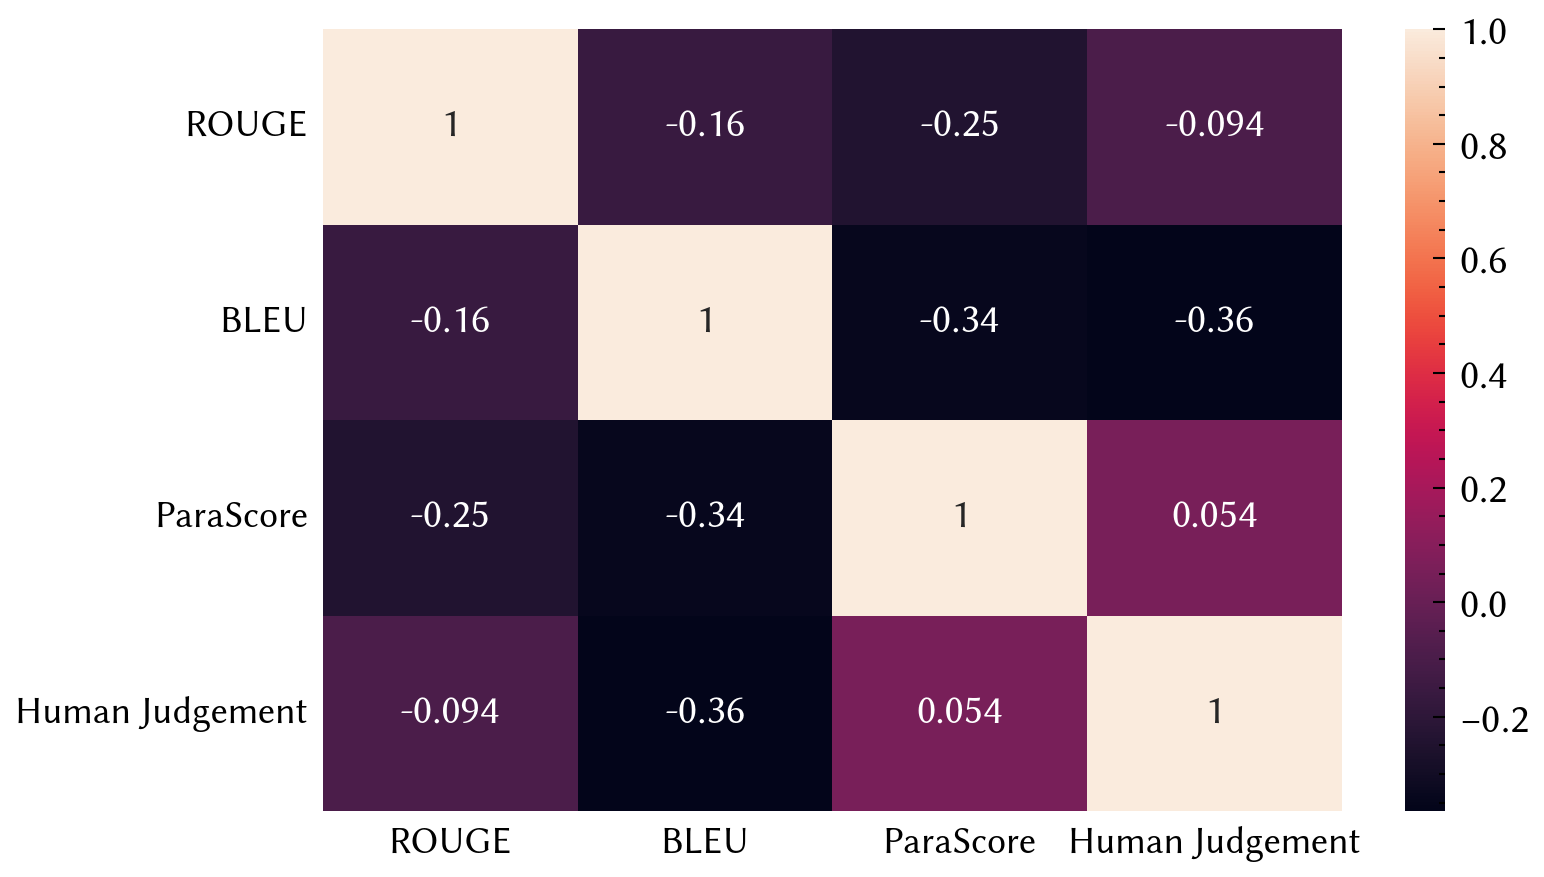

In [99]:
# Generate dummy scores for human rankings and automated metrics (ROUGE, BLEU, ParaScore)
rouge_scores = np.random.uniform(0.4, 0.9, size=10)  # ROUGE scores
bleu_scores = np.random.uniform(0.3, 0.8, size=10)  # BLEU scores
parascale_scores = np.random.uniform(0.5, 0.95, size=10)  # ParaScore
human_scores = np.random.uniform(0.5, 0.95, size=10) 

# Create a DataFrame for correlation matrix
data = {
    'ROUGE': rouge_scores,
    'BLEU': bleu_scores,
    'ParaScore': parascale_scores,
    'Human Judgement': human_scores
}
df = pd.DataFrame(data)

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set figure size according to the provided description


# Create a heatmap for the correlation matrix
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

sns.heatmap(corr_matrix, annot=True, ax=ax, annot_kws={"fontsize": 10})

# Remove only the tick marks (but keep the labels)
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelsize=9)  # Remove tick marks on the x-axis
ax.tick_params(axis='y', which='both', left=False, right=False, labelsize=9)  # Remove tick marks on the y-axis

# Save the correlation matrix as a PDF
output_path = os.path.join(output_dir, "correlation_matrix.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()


## New metric

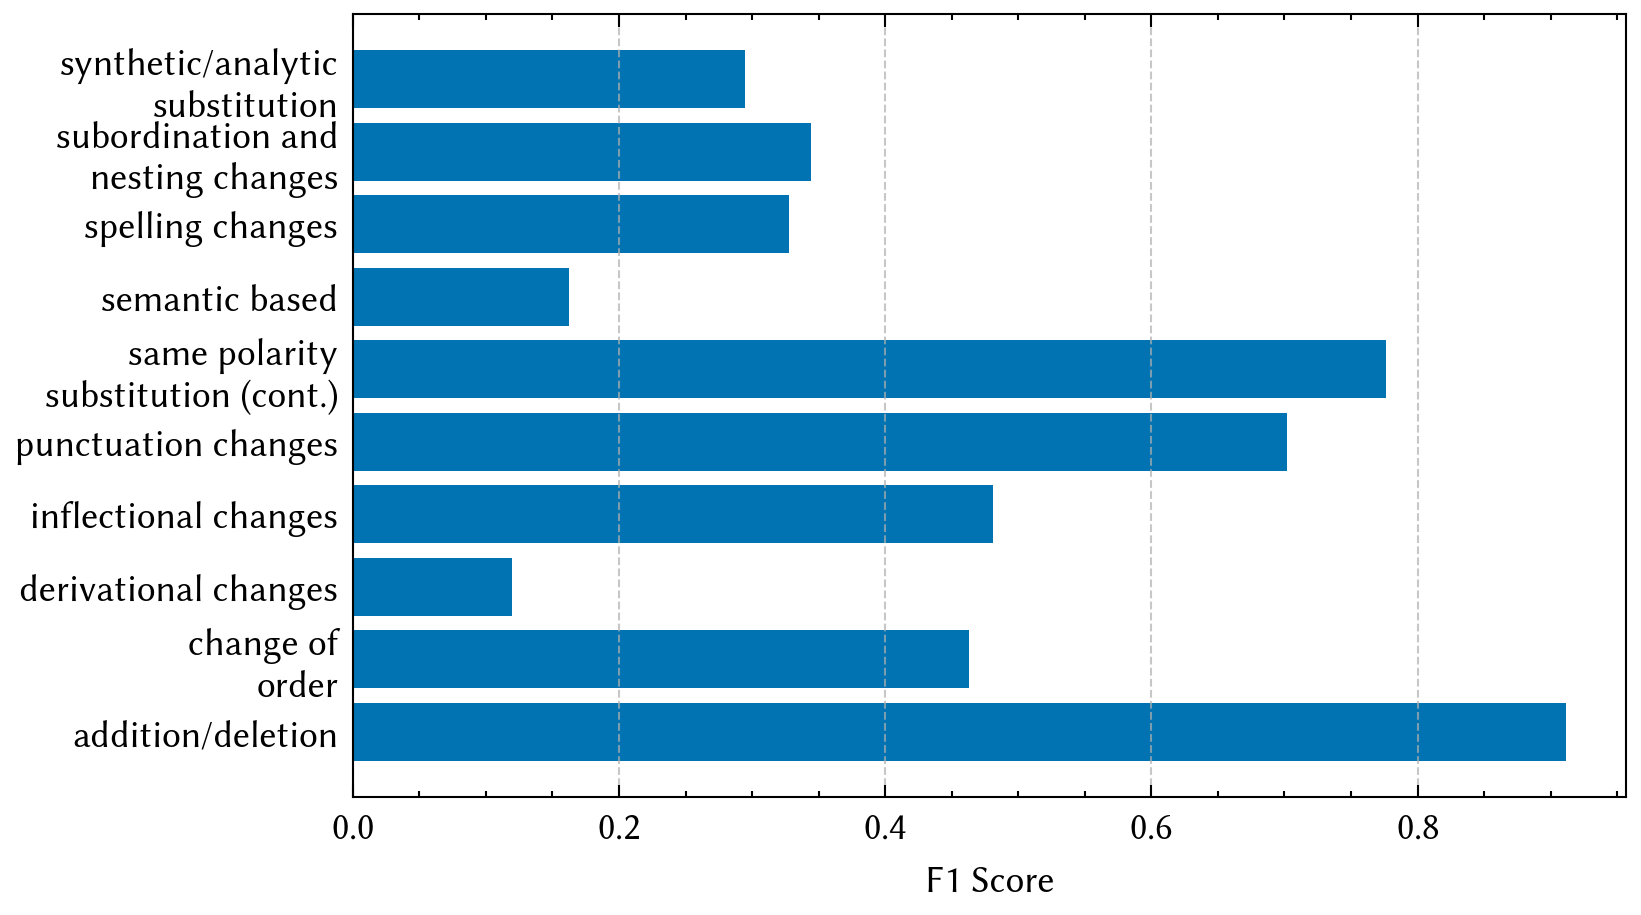

In [100]:
classification_data = pd.read_csv('/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_ptd_results_hyperclass_20241024_161522.csv', skiprows=14)

def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "synthetic/analytic substitution":
        return "synthetic/analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "same polarity\nsubstitution (cont.)"
    
    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(' ')
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

classification_data['Paraphrase Type'] = classification_data['Paraphrase Type'].apply(lambda x: add_line_breaks(x, n=2))

# Extract F1 scores for each paraphrase type, excluding rows like 'micro avg', 'macro avg', etc.
paraphrase_f1_scores = classification_data[~classification_data['Paraphrase Type'].str.contains('avg')]

# Create the plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

plt.barh(paraphrase_f1_scores['Paraphrase Type'], paraphrase_f1_scores['F1-score'])

plt.xlabel('F1 Score', fontsize=9)
ax.tick_params(axis='x', which='both', labelsize=9)  # Set x-axis labels to size

plt.grid(axis='x', linestyle='--', alpha=0.7)

ax.tick_params(axis='y', which='both', left=False, right=False, labelsize=9)  # Remove tick marks on the y-axis

output_path = os.path.join(output_dir, "new_type_score.pdf")
plt.savefig(output_path, dpi=300)

plt.show()


In [147]:
TOP_10_PARAPHRASE_TYPES = [
    "additiondeletion", "change of order", "derivational changes", "inflectional changes",
    "punctuation changes", "same polarity substitution (contextual)", "semantic based",
    "spelling changes", "subordination and nesting changes", "syntheticanalytic substitution"
]

class ParaphraseTypeEvaluator:
    def __init__(self, model_name: str, top_k: int = 10):
        self.model_name = model_name
        self.top_k = top_k
        self.model = AutoModelForSequenceClassification.from_pretrained(model_name, local_files_only=True)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name, clean_up_tokenization_spaces=True)
        self.model.eval()
        self.normalized_top_10_types = [ptype.strip().lower() for ptype in TOP_10_PARAPHRASE_TYPES]

    def preprocess_apt(self, apt: str) -> List[str]:
        apt_types = apt.lower().split(", ")
        filtered_types = [
            ptype.strip() for ptype in apt_types if ptype.strip() in self.normalized_top_10_types
        ]
        return filtered_types

    def extract_paraphrase(self, paraphrase_list: List[str]) -> str:
        """Extracts the actual paraphrase text from the given list entry."""
        # Ensure the list has the expected structure and process the second element.
        if len(paraphrase_list) >= 2:
            paraphrase_entry = paraphrase_list[1]
            # Extract text after 'Generated Paraphrase:' and clean it up.
            match = re.search(r"Generated Paraphrase:(.*)", paraphrase_entry, re.IGNORECASE)
            if match:
                # Extract everything after 'Generated Paraphrase:'
                cleaned_paraphrase = match.group(1).strip()
                
                # If there are multiple numbered paraphrases, extract only the first one.
                # Look for "1." and "2."
                numbered_match = re.search(r"1\.\s*(.*?)(?=\s*2\.)", cleaned_paraphrase, re.DOTALL)
                if numbered_match:
                    return numbered_match.group(1).strip()
                
                return cleaned_paraphrase
        return ""

    def predict_paraphrase_types(self, reference: str, paraphrase: str) -> List[str]:
        inputs = self.tokenizer(reference, paraphrase, truncation=True, max_length=256, return_tensors="pt")
        with torch.no_grad():
            logits = self.model(**inputs).logits
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()
        
        top_k_indices = np.argsort(probs)[-self.top_k:][::-1]  # Descending order
        predicted_types = [TOP_10_PARAPHRASE_TYPES[idx] for idx in top_k_indices if probs[idx] > 0.5]
        return predicted_types
    @staticmethod    
    def calculate_f1(tp: int, fp: int, fn: int) -> float:
        """Calculate F1 score using the sklearn-style formula."""
        denominator = (2 * tp) + fp + fn
        return (2 * tp) / denominator if denominator > 0 else 0.0

    def evaluate(self, json_file_path: str) -> pd.DataFrame:
            with open(json_file_path, 'r', encoding='utf-8') as file:
                data = json.load(file)
            
            model_scores = {}
            single_accuracies = {}
            type_accuracies = {ptype: {} for ptype in TOP_10_PARAPHRASE_TYPES}
            paraphrase_type_f1 = {ptype: {} for ptype in TOP_10_PARAPHRASE_TYPES}
            # Initialize counters for agreement metrics
            human_annotations={}
            type_labels = {ptype: {} for ptype in TOP_10_PARAPHRASE_TYPES}

            for entry in data:
                reference = entry["data"]["Original"]
                true_types = self.preprocess_apt(entry["data"]["APT"])
                model_name = entry["data"]["Kind"]
                paraphrase = self.extract_paraphrase(entry["data"]["Paraphrase"])                
                              
                predicted_types = self.predict_paraphrase_types(reference, paraphrase)

                # Store true and predicted labels for each paraphrase type
                for ptype in TOP_10_PARAPHRASE_TYPES:
                    if model_name not in type_labels[ptype]:
                        type_labels[ptype][model_name] = {"true_labels": [], "predicted_labels": []}
                    
                    # True label: 1 if the current type is in true_types, 0 otherwise
                    ptype_true_label = 1 if any(
                        res['value']['choices'][0] == "Yes" and res['from_name'] == "APT"
                        for res in entry["annotations"][0]["result"]
                    ) else 0
                    # Predicted label: 1 if the current type is in predicted_types, 0 otherwise
                    ptype_pred_label = 1 if ptype in predicted_types else 0
                    
                    type_labels[ptype][model_name]["true_labels"].append(ptype_true_label)
                    type_labels[ptype][model_name]["predicted_labels"].append(ptype_pred_label)

                

                                
                # Calculate single accuracy: if any true type is in predicted types.
                correct_prediction = any(ptype in predicted_types for ptype in true_types)
                if model_name not in single_accuracies:
                    single_accuracies[model_name] = {"correct": 0, "total": 0}
                single_accuracies[model_name]["correct"] += int(correct_prediction)
                single_accuracies[model_name]["total"] += 1

                # Update type-specific accuracies.
                for ptype in TOP_10_PARAPHRASE_TYPES:
                    if model_name not in type_accuracies[ptype]:
                        type_accuracies[ptype][model_name] = {"correct": 0, "total": 0}
                    if ptype in true_types:
                        type_accuracies[ptype][model_name]["total"] += 1
                        if ptype in predicted_types:
                            type_accuracies[ptype][model_name]["correct"] += 1
                            
                    # Calculate F1 scores by paraphrase type for each model
            paraphrase_type_f1_scores = {
                ptype: {
                    model: self.calculate_f1(
                        counts["tp"], counts["fp"], counts["fn"]
                    )
                    for model, counts in paraphrase_type_f1[ptype].items()
                }
                for ptype in TOP_10_PARAPHRASE_TYPES
            }


            # Calculate the average F1 score for each model
            avg_model_scores = {
                model: np.mean(scores) for model, scores in model_scores.items()
            }

            # Calculate single accuracy for each model
            model_single_accuracies = {
                model: (counts["correct"] / counts["total"]) * 100 if counts["total"] > 0 else 0
                for model, counts in single_accuracies.items()
            }

            # Calculate type-specific accuracy for each model and paraphrase type
            model_type_accuracies = {
                ptype: {
                    model: (counts["correct"] / counts["total"]) * 100 if counts["total"] > 0 else 0
                    for model, counts in type_accuracies[ptype].items()
                }
                for ptype in TOP_10_PARAPHRASE_TYPES
            }
            
            # Calculate accuracy and F1 score with human annotation for each model
            human_annotation_results = {
                model: {
                    "f1_with_human_annotation": f1_score(ann["true_labels"], ann["predicted_labels"], average='macro', zero_division=1),
                    "accuracy_with_human_annotation": sum(1 for t, p in zip(ann["true_labels"], ann["predicted_labels"]) if t == p) / len(ann["true_labels"]) * 100
                }
                for model, ann in human_annotations.items()
            }


            # Create a DataFrame from the scores, including the type-specific accuracies
            df_data = []
            for model in avg_model_scores:
                row = {
                    "Model": model,
                    "Average F1 Score": avg_model_scores[model],
                    "Single Accuracy": model_single_accuracies[model],
                    "F1 with Human Annotation": human_annotation_results[model]["f1_with_human_annotation"],
                    "Accuracy with Human Annotation": human_annotation_results[model]["accuracy_with_human_annotation"]
                }
                # Add each paraphrase type's accuracy to the row
                for ptype in TOP_10_PARAPHRASE_TYPES:
                    row[f"{ptype} accuracy"] = model_type_accuracies[ptype].get(model, 0)
                df_data.append(row)
            ###############################
                
            # Calculate F1 scores for each paraphrase type and model
            paraphrase_type_f1_scores = {
                ptype: {
                    model: f1_score(
                        labels["true_labels"],
                        labels["predicted_labels"],
                        average="binary",
                        zero_division=1
                    )
                    for model, labels in type_labels[ptype].items()
                }
                for ptype in TOP_10_PARAPHRASE_TYPES
            }

            # Create a DataFrame from the scores
            df_data = []
            for ptype, model_scores in paraphrase_type_f1_scores.items():
                for model, f1 in model_scores.items():
                    row = {
                        "Paraphrase Type": ptype,
                        "Model": model,
                        "F1 Score": f1,
                    }
                    df_data.append(row)
                    
            # Convert to DataFrame
            df = pd.DataFrame(df_data)
            
            return df

evaluator = ParaphraseTypeEvaluator(model_name="/home/slim/dpo-rhlf-paraphrase-types/out/cls-models/deberta-base_qqp_pd_etpc_ptd")
df_results = evaluator.evaluate(json_file_path="/home/slim/dpo-rhlf-paraphrase-types/out/gen-models/project-5-at-2024-10-21-12-25-522ea966.json")


In [148]:
df_results

,Paraphrase Type,Model,F1 Score
0,additiondeletion,base_model,0.172414
1,additiondeletion,etpc_model,0.175439
2,additiondeletion,dpo_model,0.134615
3,change of order,base_model,0.181818
4,change of order,etpc_model,0.058824
5,change of order,dpo_model,0.222222
6,derivational changes,base_model,0.166667
7,derivational changes,etpc_model,0.166667
8,derivational changes,dpo_model,0.352941
9,inflectional changes,base_model,0.250000


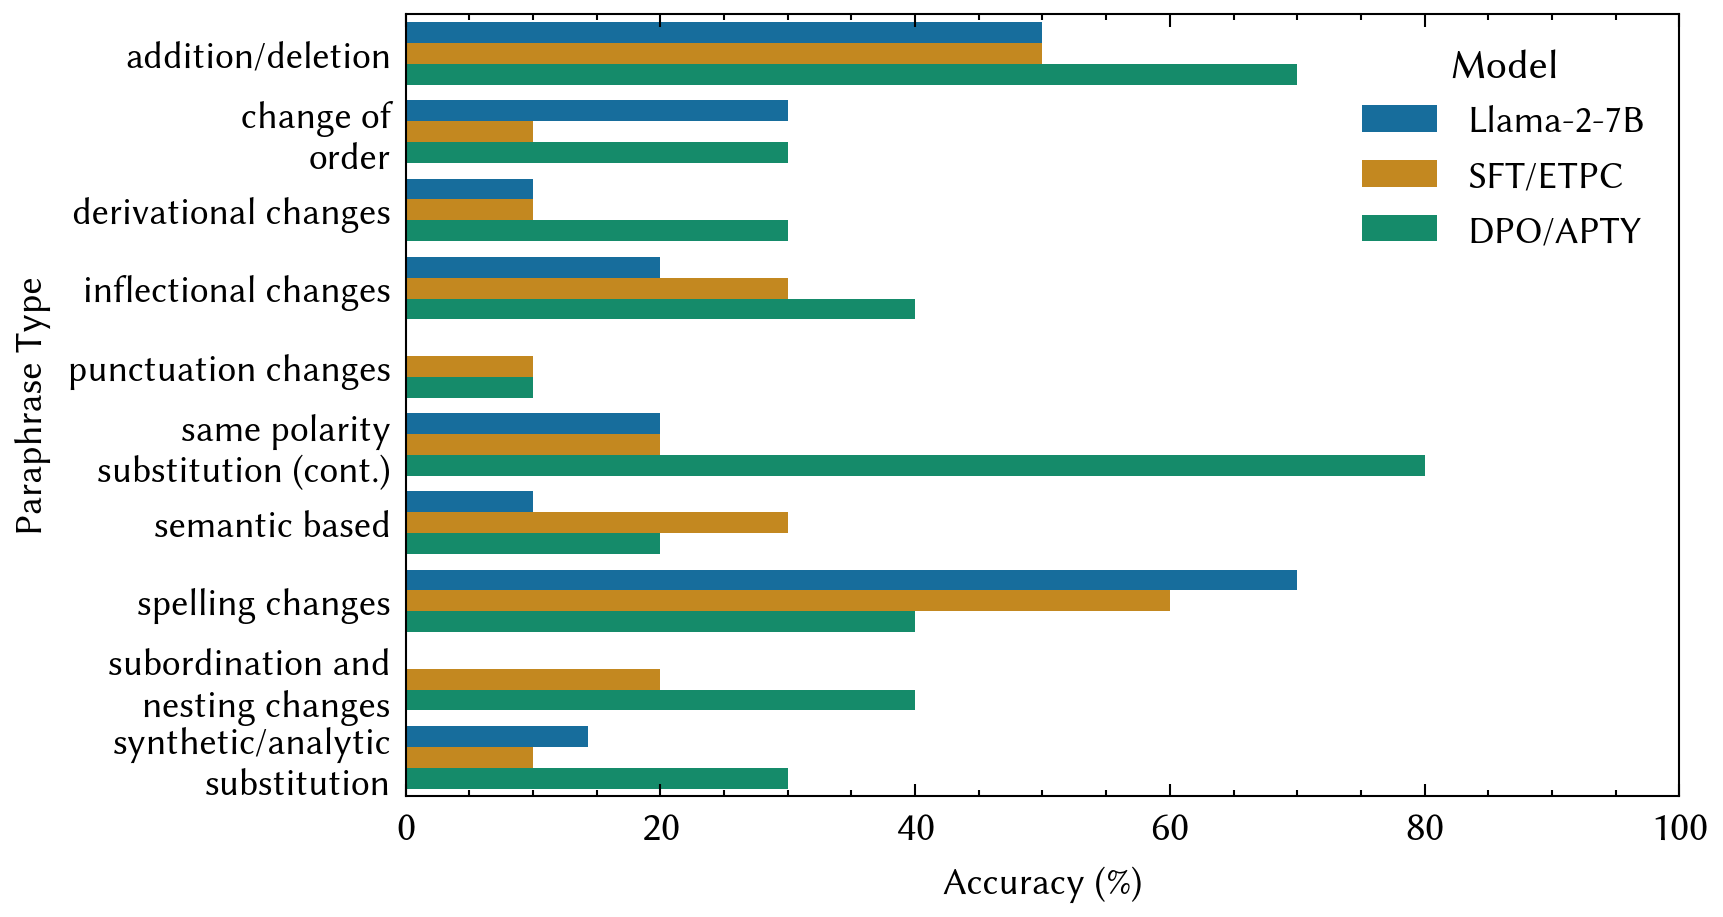

In [141]:
# Melt the DataFrame to have a suitable format for plotting
df_melted = df_results.melt(
    id_vars=['Model'],
    value_vars=[f"{ptype} accuracy" for ptype in TOP_10_PARAPHRASE_TYPES],
    var_name='Paraphrase Type',
    value_name='Accuracy'
)
df_melted['Paraphrase Type'] = df_melted['Paraphrase Type'].str.replace(" accuracy", "")

def add_line_breaks(text, n=2):
    # Add a custom line break for "synthetic/analytic substitution"
    if text == "syntheticanalytic substitution":
        return "synthetic/analytic\nsubstitution"
    if text == "same polarity substitution (contextual)":
        return "same polarity\nsubstitution (cont.)"
    if text == "additiondeletion":
        return "addition/deletion"
    
    # Otherwise, split the text into words and add line breaks every `n` words
    words = text.split(' ')
    lines = [' '.join(words[i:i + n]) for i in range(0, len(words), n)]
    return '\n'.join(lines)

df_melted['Paraphrase Type'] = df_melted['Paraphrase Type'].apply(lambda x: add_line_breaks(x, n=2))


# Define the mapping for model names
model_rename_mapping = {
    "base_model": "Llama-2-7B",
    "etpc_model": "SFT/ETPC",
    "dpo_model": "DPO/APTY"
}

# Rename the models in the 'Model' column using the mapping
df_melted['Model'] = df_melted['Model'].replace(model_rename_mapping)

# Create a bar plot
fig, ax = plt.subplots(figsize=(width1, height1), dpi=300)
plt.style.use(['science', 'no-latex'])
sns.set_palette("colorblind")
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Linux Biolinum O', 'Linux Biolinum', 'Biolinum']

# Create the bar plot with updated model names
sns.barplot(
    data=df_melted,
    y='Paraphrase Type',
    x='Accuracy',
    hue='Model'
)

# Customize the plot
plt.ylabel('Paraphrase Type', fontsize=9)
ax.tick_params(axis='y', which='both', left=False, right=False, labelsize=9)  # Remove tick marks on the y-axis
plt.xlabel('Accuracy (%)', fontsize=9)
plt.xlim(0, 100)
plt.legend(
    title='Model',
    fontsize=9,
    #bbox_to_anchor=(0.7, 0.7),  # Move it to the right and down a bit
    #loc='center left',  # Align it to the center-left relative to the anchor
)
plt.yticks(fontsize=9)  

output_path = os.path.join(output_dir, "new_types.pdf")
plt.savefig(output_path, dpi=300)

# Show the plot
plt.show()

